# Ejercicio 01 · Dataset público y SVM reproducible

Marlenis Judith Concepción Cuevas · INF-8239-C2

Ionosphere es una propuesta pendiente de aprobación docente. Se siguen los mandatos y rúbricas compartidos; faltan los capítulos completos LAB01–LAB03.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
from IPython.display import display, Image, Markdown

## Protocolo
Separación estratificada 60/20/20, semilla 42. Duplicados exactos retirados antes de la partición; ninguna transformación se ajusta con validación o prueba. Métrica principal: F1 macro. El test no decide parámetros ni configuraciones.

In [2]:
from laboratorio_e01 import ejecutar
resultados = ejecutar()
display(resultados)

/Users/mjcc/Library/Mobile Documents/com~apple~CloudDocs/Documents/CienciadeDatosII/Ciencia de DatosII/Unidad I/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


  modelo     particion  accuracy  f1_macro  precision_macro  recall_b  recall_g  roc_auc
Baseline entrenamiento    0.6429    0.3913           0.3214    0.0000    1.0000   0.5000
Baseline    validacion    0.6429    0.3913           0.3214    0.0000    1.0000   0.5000
Baseline        prueba    0.6429    0.3913           0.3214    0.0000    1.0000   0.5000
     SVM entrenamiento    0.9857    0.9844           0.9859    0.9733    0.9926   0.9998
     SVM    validacion    0.9571    0.9529           0.9574    0.9200    0.9778   0.9956
     SVM        prueba    0.9429    0.9378           0.9378    0.9200    0.9556   0.9707
Auditoría: {'filas_originales': 351, 'filas_utilizadas': 350, 'duplicados_eliminados': 1, 'faltantes': 0, 'columnas_constantes': ['atributo_02'], 'clases': {'g': 225, 'b': 126}, 'sha256_datos': '46d52186b84e20be52918adb93e8fb9926b34795ff7504c24350ae0616a04bbd', 'particiones': {'entrenamiento': 210, 'validacion': 70, 'prueba': 70}, 'semilla': 42, 'aprobacion_docente': 'pendie

,modelo,particion,accuracy,f1_macro,precision_macro,recall_b,recall_g,roc_auc
0,Baseline,entrenamiento,0.642857,0.391304,0.321429,0.000000,1.000000,0.500000
1,Baseline,validacion,0.642857,0.391304,0.321429,0.000000,1.000000,0.500000
2,Baseline,prueba,0.642857,0.391304,0.321429,0.000000,1.000000,0.500000
3,SVM,entrenamiento,0.985714,0.984398,0.985890,0.973333,0.992593,0.999802
4,SVM,validacion,0.957143,0.952904,0.957428,0.920000,0.977778,0.995556
5,SVM,prueba,0.942857,0.937778,0.937778,0.920000,0.955556,0.970667


In [3]:
display(Markdown((ROOT / 'reports/seleccion_dataset.md').read_text()))

# Comparación de datasets y solicitud de aprobación

| Criterio | Ionosphere (propuesto) | Banknote Authentication |
|---|---|---|
| Fuente | UCI, dataset 52 | UCI, dataset 267 |
| Registros / predictores | 351 / 34 | 1372 / 4 |
| Problema | Clasificar retornos de radar g/b | Clasificar especímenes de billetes |
| Procedencia | Radar de Goose Bay, Labrador | Características de imágenes mediante wavelets |
| Licencia | CC BY 4.0 | CC BY 4.0 |
| Faltantes según UCI | No | No |
| Ventaja | Más dimensiones para estudiar PCA y SVM | Tamaño pequeño y descarga sencilla |
| Limitación | Pocas observaciones y contexto histórico de un radar | Solo cuatro predictores para reducción dimensional |

**Pregunta:** ¿Puede un pipeline SVM clasificar retornos de radar como buenos (`g`) o malos (`b`) y superar una predicción constante, con evaluación separada del entrenamiento?

**Decisión propuesta:** Ionosphere, por su dimensionalidad y bajo costo de experimentación. No se seleccionó por el resultado en prueba.

**Aprobación docente: PENDIENTE.** Falta registrar la confirmación real del profesor. No se ha solicitado en su nombre ni se ha inventado una aprobación.

**Fuentes y atribución:**
- Sigillito, V., Wing, S., Hutton, L., y Baker, K. (1989). Ionosphere. UCI. https://doi.org/10.24432/C5W01B · https://archive.ics.uci.edu/dataset/52/ionosphere
- Lohweg, V. (2012). Banknote Authentication. UCI. https://doi.org/10.24432/C55P57 · https://archive.ics.uci.edu/dataset/267/banknote+authentication

Fuentes consultadas el 23 de septiembre de 2026. No hay identificadores personales en las variables seleccionadas. No se afirma representatividad fuera del radar de origen ni ausencia general de sesgo.


In [4]:
import json
display(json.loads((ROOT / 'reports/auditoria.json').read_text()))
display(pd.read_csv(ROOT / 'reports/diccionario.csv'))
display(pd.read_csv(ROOT / 'reports/busqueda_cv.csv')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

{'filas_originales': 351,
 'filas_utilizadas': 350,
 'duplicados_eliminados': 1,
 'faltantes': 0,
 'columnas_constantes': ['atributo_02'],
 'clases': {'g': 225, 'b': 126},
 'sha256_datos': '46d52186b84e20be52918adb93e8fb9926b34795ff7504c24350ae0616a04bbd',
 'particiones': {'entrenamiento': 210, 'validacion': 70, 'prueba': 70},
 'semilla': 42,
 'aprobacion_docente': 'pendiente'}

,variable,tipo,rol,descripcion,faltantes
0,atributo_01,int64,predictor,Atributo 1 de la señal procesada por autocorre...,0
1,atributo_02,int64,predictor,Atributo 2 de la señal procesada por autocorre...,0
2,atributo_03,float64,predictor,Atributo 3 de la señal procesada por autocorre...,0
3,atributo_04,float64,predictor,Atributo 4 de la señal procesada por autocorre...,0
4,atributo_05,float64,predictor,Atributo 5 de la señal procesada por autocorre...,0
5,atributo_06,float64,predictor,Atributo 6 de la señal procesada por autocorre...,0
6,atributo_07,float64,predictor,Atributo 7 de la señal procesada por autocorre...,0
7,atributo_08,float64,predictor,Atributo 8 de la señal procesada por autocorre...,0
8,atributo_09,float64,predictor,Atributo 9 de la señal procesada por autocorre...,0
9,atributo_10,float64,predictor,Atributo 10 de la señal procesada por autocorr...,0


,params,mean_test_score,std_test_score,rank_test_score
9,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.941679,0.031401,1
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.934798,0.057398,2
8,"{'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel'...",0.927696,0.025187,3
10,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.924528,0.043973,4
11,"{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel...",0.922978,0.032121,5
7,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.886597,0.072647,6
2,"{'svm__C': 10, 'svm__kernel': 'linear'}",0.855288,0.050118,7
1,"{'svm__C': 1, 'svm__kernel': 'linear'}",0.829006,0.069287,8
0,"{'svm__C': 0.1, 'svm__kernel': 'linear'}",0.795759,0.039882,9
3,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.493577,0.062983,10


,fila_original,real,prediccion,error
10,52,1,0,True
29,144,0,1,True
33,174,0,1,True
37,189,1,0,True


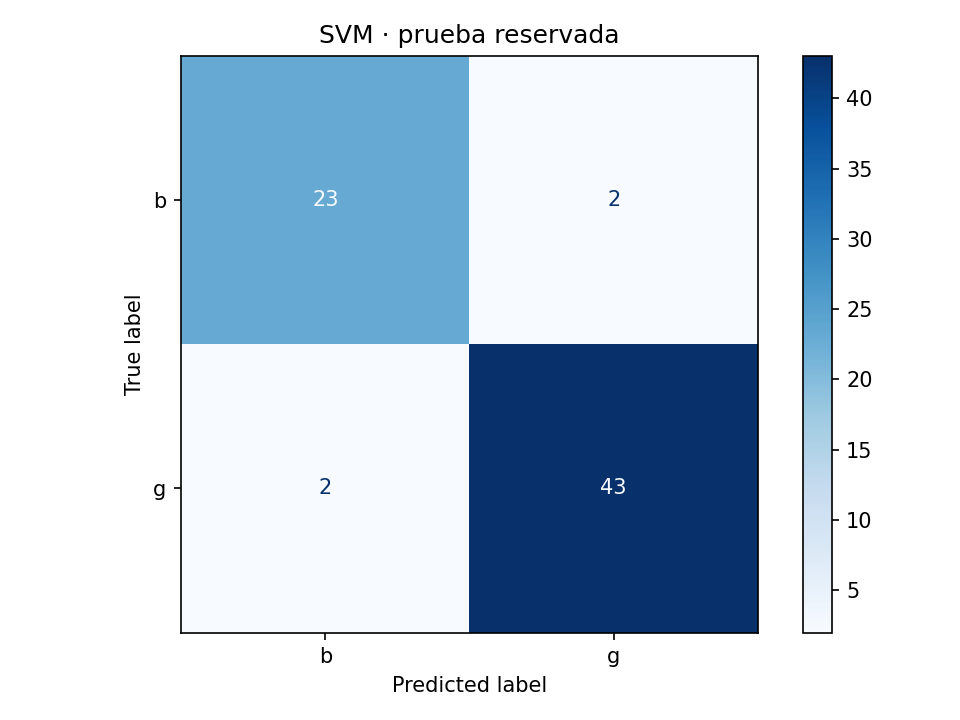

In [5]:
errores = pd.read_csv(ROOT / 'reports/predicciones_prueba.csv')
display(errores[errores.error])
display(Image(filename=str(ROOT / 'reports/matriz_confusion.png')))

In [6]:
from informe import generar
generar()
display(Markdown((ROOT / "reports/conclusion.md").read_text()))

PDF 01 y conclusión generados: 367 palabras


# Conclusión · borrador para revisión personal

El experimento examinó si un pipeline SVM podía clasificar retornos de radar y superar una regla constante. Se utilizó Ionosphere, procedente de UCI y distribuido con licencia CC BY 4.0. La comparación previa con Banknote Authentication favoreció provisionalmente Ionosphere porque sus 34 atributos permiten estudiar posteriormente reducción dimensional. Esta selección sigue pendiente de aprobación docente; la ejecución técnica no sustituye ese requisito académico.

La auditoría identificó 351 registros originales, ningún valor faltante y un duplicado exacto. Se retiró ese duplicado antes de particionar para impedir que una observación idéntica apareciera en conjuntos diferentes. Quedaron 350 registros: 210 para entrenamiento, 70 para validación y 70 para prueba. Se mantuvo una columna constante, cuyo escalamiento es manejado por el pipeline, para conservar el esquema original. La clase objetivo se separó de los predictores y los índices de las particiones quedaron registrados.

La búsqueda comparó kernels lineal y RBF con validación cruzada estratificada de cinco pliegues exclusivamente sobre entrenamiento. La imputación y el escalamiento se ajustaron dentro de cada pliegue. La configuración seleccionada fue rbf, con C=10 y gamma=scale. El baseline predijo siempre la clase mayoritaria. En prueba, su F1 macro fue 0.391, mientras que el SVM alcanzó 0.938, una diferencia de 0.546. La exactitud del SVM fue 0.943; se priorizó F1 macro para representar ambas clases.

El F1 macro descendió de 0.984 en entrenamiento a 0.953 en validación y 0.938 en prueba. Esta diferencia exige cautela frente al sobreajuste, aunque no elimina la mejora respecto a la referencia. Hubo 4 errores entre las 70 observaciones de prueba. El recall fue 0.920 para retornos malos y 0.956 para buenos; la matriz de confusión permite distinguir los errores en ambas direcciones. Sin información adicional de adquisición no se puede atribuir causalmente cada fallo a una característica concreta.

Los resultados respaldan continuar con la comparación de ensambles, pero no garantizan desempeño fuera de este radar histórico. El pequeño tamaño de prueba limita la precisión de las estimaciones y no se calculó un intervalo de confianza. La descarga verificada, las semillas, las pruebas y el código reutilizable facilitan reproducir el procedimiento. Antes de entregar corresponde confirmar la aprobación del dataset, contrastar los laboratorios completos y revisar esta conclusión para poder defender sus decisiones.


## Fuentes y límites
[UCI Ionosphere](https://archive.ics.uci.edu/dataset/52/ionosphere), CC BY 4.0.
[Prevención de fuga, scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html).
[Documentación t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).

La muestra histórica de un radar no permite afirmar generalización a otros radares. Las conclusiones son un borrador basado en ejecuciones reales que la estudiante debe revisar y defender.